# Automatic Gradient

## Author: RAHUL KP KURUP

This notebook implemtes a minimal automatic differentiation engine and builds a neural network (MLP) from scratch.

# Features
- Autograd Engine
- Backpropagation using topological sort
- Activation Function: Tanh, ReLu, Sigmoid
- Neural network: Neuron -> Layer -> MLP
- Visualization support (Graphviz)
- Reference : https://github.com/karpathy/micrograd/blob/master/micrograd/engine.py

# Core AutoGradient Engine

## Object Creation

In [1]:
import math

class Value:

    def __init__(self, data, children=(), _op='', label=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(children)
        self._op = _op
        self.label = label

v = Value(5)
print(v)
v.grad = 2
v._op = '+'
v.label = '+'
print(v.data, v.grad, v.label, v._op)

5.0 2 + +


## repr function

In [2]:
import math
class sample:
    def __init__(self, data):
        self.data = data
        self.grad = 0

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

v = sample(5)
print(v)

Value(data=5, grad=0)


## Adition function

### Gradient of Addition

We want to compute the derivative:

$$\frac{d}{dx}(x + x) = ?$$

**Step-by-step**

Simplify the expression:

$$x + x = 2x$$

Now differentiate:

$$\frac{d}{dx}(2x) = 2$$

**Final Answer**

$$\frac{d}{dx}(x + x) = 2$$

**Intuition**

- Each variable contributes a gradient of **1**
- So:
  - First x → 1
  - Second x → 1

 Total:

$$1 + 1 = 2$$

In [3]:
# Simple numerical verification
import numpy as np

def f(x):
    return x + x

x = 5
h = 1e-5

# Numerical derivative 
grad = (f(x + h) - f(x - h)) / (2 * h)

print('Numerical Gradient:', grad)

Numerical Gradient: 1.9999999999242843


In [4]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        self._children = _children   # computation graph
        self._op = _op               # operation
        self._backward = lambda: None  # default empty function

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        # Ensure both are Value objects
        other = other if isinstance(other, Value) else Value(other)
        
        # Create output node
        out = Value(self.data + other.data, (self, other), '+')

        # Define backward function (INSIDE)
        def _backward():
        # Gradient rule:
        # d/dx (x + x) = 2
        # More generally:
        # d/dself (self + other) = 1
        # d/dother (self + other) = 1
        # So each input receives the full upstream gradient (out.grad)
            self.grad += out.grad
            other.grad += out.grad

        # Attach backward function to output node
        out._backward = _backward

        return out
v1 = Value(10)
# v2 = Value(5)
v2 = 10
result = v1 + v2
print(result)
    

Value(data=20, grad=0)


## Multiplication Function

### Gradient of Multiplication

We want to compute the derivative:

$$\frac{d}{dx}(x \cdot x) = ?$$

**Step-by-step**

Simplify the expression:

$$x \cdot x = x^2$$

**Final Answer**

$$\frac{d}{dx}(x \cdot x) = 2x$$

**Intuition**

- Each variable contributes the other variable
- So:
  - First x → contributes x
  - Second x → contributes x

Total:

$$x + x = 2x$$

In [5]:
import numpy as np

def f(x):
    return x * x

x = 5
h = 1e-5

# Numerical derivative
grad = (f(x + h) - f(x - h)) / (2 * h)

print('Numerical Gradient:', grad)

Numerical Gradient: 9.999999999621423


In [6]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        self._children = _children   # computation graph
        self._op = _op               # operation
        self._backward = lambda: None  # default empty function

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


    def __mul__(self, other):
        # Ensure both are Value objects
        other = other if isinstance(other, Value) else Value(other)
        
        # Create output node
        out = Value(self.data * other.data, (self, other), '*')

        # Backward function
        def _backward():
            # Gradient rule:
            # d/dself (self * other) = other
            # d/dother (self * other) = self
            # Apply chain rule with out.grad
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

**Declare Objects**

In [7]:
v1 = Value(4)
v2 = 4   # auto-converted

**Forward Pass**

In [8]:
result_mul = v1 * v2
print("Multiplication:", result_mul, "\nV1: ", v1, "\nV2: ",v2)

Multiplication: Value(data=16, grad=0) 
V1:  Value(data=4, grad=0) 
V2:  4


**Gradient Calculate only when backward pass**

In [9]:
result_mul.grad = 1 # Seed gradient
result_mul._backward()
print("Multiplication:", result_mul, "\nV1: ", v1, "\nV2: ",v2)

Multiplication: Value(data=16, grad=1) 
V1:  Value(data=4, grad=4) 
V2:  4


### Seed Gradient in Backpropagation

```python
result_mul.grad = 1
```

**Why?**

Because mathematically:

$$\frac{d(\text{output})}{d(\text{output})} = 1$$

This is the starting point of backpropagation.

**What should happen mathematically**

If:

$$y = x \cdot 4$$

Then:

$$\frac{dy}{dx} = 4$$

**Chain Rule Explanation**

Backpropagation applies the chain rule:

$$\frac{dy}{dx} = \frac{dy}{dy} \cdot \frac{d(x \cdot 4)}{dx}$$

$$= 1 \cdot 4 = 4$$

### Understanding Gradients

**real gradients in action**. Let’s interpret the output precisely.

**Our Output**

```
Multiplication: Value(data=16, grad=1)
V1: Value(data=4, grad=8)
V2: 4
```

**Our computation is**

```python
v1 = Value(4)
v2 = 4
result_mul = v1 * v2
```

Mathematically:

$$y = x \cdot 4$$

Where:
- x = v1 = 4
- y = result = 16

### Meaning of Each Gradient

**result_mul.grad = 1**

This is the seed gradient:

$$\frac{dy}{dy} = 1$$

Meaning:
- Output depends on itself fully
- So gradient = 1 (always)

**v1.grad = 8**

From our code:

```python
self.grad += other.data * out.grad
```

Substitute values:

```python
v1.grad += 4 * 1
```

Expected:

$$\frac{dy}{dx} = 4$$

we got:

```
v1.grad = 4
```

**Important Rule**

```python
self.grad += ...
```

Gradients are **accumulated**, not replaced.
**Example:**
```
First run → 4
Second run → 4 + 4 = 8
```

**Intuition** 

> Gradient = “How much output changes if input changes”

> v1.grad = 4 → Increasing x by 1 increases output by 4

> Gradients accumulate — if you don’t reset, they stack.

## Power Function

### Gradient of Power

$$\frac{d}{dx}(x^n) = n \cdot x^{n-1}$$

Our implementation:

```python
self.grad += other * (self.data**(other-1)) * out.grad
```

- Depends only on `self`
- `other` is treated as constant

**Convertion not needed**

The line:

```python
other = other if isinstance(other, Value) else Value(other)
```

is **not needed in `__pow__`** because:

> `other` is treated as a constant (scalar), not a variable.

**Deep Explanation**

**In `__add__` and `__mul__`**

```python
other = other if isinstance(other, Value) else Value(other)
```

**needed?**

Because both operands are variables:

```python
v1 + v2
v1 * v2
```

- Both can require gradients
- So both must be `Value` objects

**In `__pow__`**

```python
def __pow__(self, other):
```

**Here:**

- `self` → variable (needs gradient)
- `other` → constant exponent

Example:

```python
x = Value(2)
y = x ** 3
```

Mathematically:

$$y = x^3$$

### Why NOT convert `other` to Value?

If we do:

```python
other = Value(other)
```

Then:
- Incorrectly treat exponent as a variable

This breaks the mathematical assumption:

$$y = x^n \quad (n \text{ is constant})$$

### Current Design

Supported:

```python
x ** 2   # True
x ** 3   # True
```

Not supported:

```python
x ** y   # False
```

Because gradient for exponent is not implemented.

In [10]:
import numpy as np

def f(x):
    return x**2

x = 3
h = 1e-5

grad = (f(x + h) - f(x - h)) / (2 * h)

print("Numerical Gradient:", grad)

Numerical Gradient: 6.000000000039306


**How gradient 6**
$$y = x^2$$
$$\frac{dy}{dx} = \frac{dx^2}{dx} = 2x = 2 \cdot 3 = 6 $$

In [11]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        self._children = _children   # computation graph
        self._op = _op               # operation
        self._backward = lambda: None  # default empty function

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __pow__(self, other):
        # other is treated as constant (scalar)
        
        # Create output node
        out = Value(self.data ** other, (self,), f'**{other}')

        # Backward function
        def _backward():
            # Gradient rule:
            # d/dx (x^n) = n * x^(n-1)
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out

In [12]:
v = Value(3)
v2 = Value(2)

result = v ** 2   # 3^2 = 9

# Backprop
result.grad = 1
result._backward()

print("Result:", result)
print("v:", v)

Result: Value(data=9, grad=1)
v: Value(data=3, grad=6)


## Activation Functions

### Tanh Activation 

**1. Forward Pass (Computation)**

```python
t = (math.exp(2*self.data)-1)/(math.exp(2*self.data)+1)
```

Mathematically:

$$\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

**Why this form?**
- Equivalent to:
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
- More numerically stable and efficient

```python
out = Value(t, (self,), 'tanh')
```

Creates a node in the computation graph:
- Value = t
- Parent = self
- Operation = 'tanh'

**2. Backward Pass (Gradient Rule)**

```python
def _backward():
    self.grad += (1 - t**2) * out.grad
```

**Gradient formula:**

$$\frac{d}{dx}(\tanh(x)) = 1 - \tanh^2(x)$$

Since:

```python
t = tanh(self.data)
```

Gradient becomes:

```python
self.grad += (1 - t**2) * out.grad
```

**Chain Rule Applied**

$$\frac{dL}{dx} = \frac{dL}{dt} \cdot \frac{dt}{dx}$$

Where:
- out.grad = dL/dt
- (1 - t^2) = dt/dx

In [13]:
import math

class Value:
    def __init__(self, data):
        self.data = data
        self.grad = 0
        self._backward = lambda: None

    def tanh(self):
        t = (math.exp(2*self.data)-1)/(math.exp(2*self.data)+1)
        out = Value(t)

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

x = Value(1.0)
y = x.tanh()

y.grad = 1
y._backward()

print('Gradient:', x.grad)

Gradient: 0.41997434161402614


**Behavior of tanh**

| Input | Output |
|------|--------|
| Large +ve | → 1 |
| Large -ve | → -1 |
| 0 | → 0 |

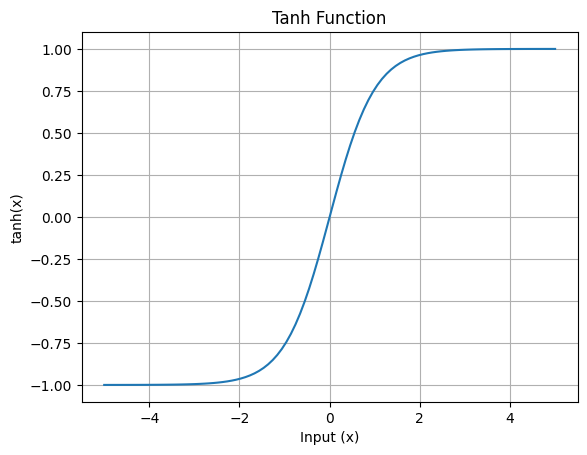

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Generate input values
x = np.linspace(-5, 5, 100)

# Compute tanh
y = np.tanh(x)

# Plot the graph
plt.figure()
plt.plot(x, y)

# Labels
plt.title("Tanh Function")
plt.xlabel("Input (x)")
plt.ylabel("tanh(x)")

# Grid
plt.grid()

plt.show()

**Limitation**

- Gradient vanishes for large inputs
- Known as the **vanishing gradient problem**

#### Vanishing Gradient in tanh

**Tanh derivative**

We know:

$$\frac{d}{dx}(\tanh(x)) = 1 - \tanh^2(x)$$

**Step 1: Behavior for Large Inputs**

Case 1: x → +∞

$$\tanh(x) \to 1$$

Substitute into derivative:

$$\frac{d}{dx}(\tanh(x)) = 1 - 1^2 = 0$$

Case 2: x → -∞

$$\tanh(x) \to -1$$

$$\frac{d}{dx}(\tanh(x)) = 1 - (-1)^2 = 0$$

Conclusion

$$\lim_{x \to \pm \infty} \frac{d}{dx}(\tanh(x)) = 0$$

Gradient approaches zero at extreme values.

**Step 2: Chain Rule in Neural Networks**

Consider:

$$L = f_3(f_2(f_1(x)))$$

Gradient:

$$\frac{dL}{dx} = \frac{dL}{df_3} \cdot \frac{df_3}{df_2} \cdot \frac{df_2}{df_1} \cdot \frac{df_1}{dx}$$

Core Problem

Each layer contributes:

$$(1 - \tanh^2(x)) \approx 0 \quad \text{for large } x$$

Thus:

$$\frac{dL}{dx} \approx 0 \cdot 0 \cdot 0 \cdot 0 = 0$$

> One-line Proof Summary

$$\tanh(x) \to \pm1 \Rightarrow (1 - \tanh^2(x)) \to 0 \Rightarrow \text{gradient vanishes}$$

> Solution ReLu Activation

### ReLU Activation

**ReLU (Rectified Linear Unit) activation function and its gradient**

**1. Forward Pass (Computation)**

```python
out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')
```

Mathematically:

$$\text{ReLU}(x) = \max(0, x)$$

**Behavior**

| Input | Output |
|------|--------|
| x < 0 | 0 |
| x = 0 | 0 |
| x > 0 | x |

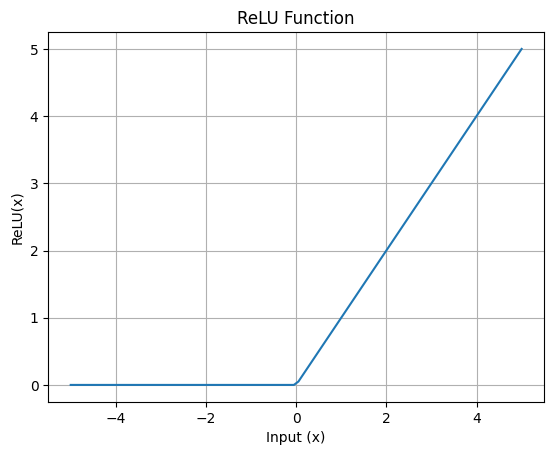

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Generate input values
x = np.linspace(-5, 5, 100)

# Compute ReLU
y = np.maximum(0, x)

# Plot the graph
plt.figure()
plt.plot(x, y)

# Labels
plt.title("ReLU Function")
plt.xlabel("Input (x)")
plt.ylabel("ReLU(x)")

# Grid
plt.grid()

plt.show()

Creates a node in the computation graph:
- Value = output
- Parent = self
- Operation = 'ReLU'

**2. Backward Pass (Gradient Rule)**

```python
def _backward():
    self.grad += (1.0 if self.data > 0 else 0.0) * out.grad
```

**Gradient formula:**

$$\frac{d}{dx} = \begin{cases} 1 & x > 0 \\ 0 & x \le 0 \end{cases}$$

**Chain Rule Applied**

$$\frac{dL}{dx} = \frac{dL}{d\text{ReLU}} \cdot \frac{d\text{ReLU}}{dx}$$

Where:
- out.grad = dL/d(ReLU)
- derivative = 1 or 0 depending on input

In [16]:
class Value:
    def __init__(self, data):
        self.data = data
        self.grad = 0
        self._backward = lambda: None

    def relu(self):
        out = Value(0 if self.data < 0 else self.data)

        def _backward():
            self.grad += (1.0 if self.data > 0 else 0.0) * out.grad

        out._backward = _backward
        return out

x = Value(5.0)
y = x.relu()

y.grad = 1
y._backward()

print('Gradient:', x.grad)

Gradient: 1.0


**ReLU is**

- Computationally simple
- Avoids vanishing gradient (for x > 0)
- Fast convergence in deep networks

**Limitation (Dying ReLU Problem)**

- If neuron outputs always < 0 → gradient = 0
- Neuron stops learning permanently

**Comparison with tanh**

| Feature | ReLU | tanh |
|--------|------|------|
| Range | [0, ∞) | (-1, 1) |
| Gradient | 1 or 0 | Smooth (but vanishes) |
| Usage | Modern ML | Older networks |

**One-line**

> ReLU = simple, fast, and avoids vanishing gradient (but can die)

### Sigmoid Activation

**1. Forward Pass (Computation)**

```python
s = 1 / (1 + math.exp(-self.data))
```

Mathematically:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

**Behavior**

| Input | Output |
|------|--------|
| Large -ve | → 0 |
| 0 | → 0.5 |
| Large +ve | → 1 |

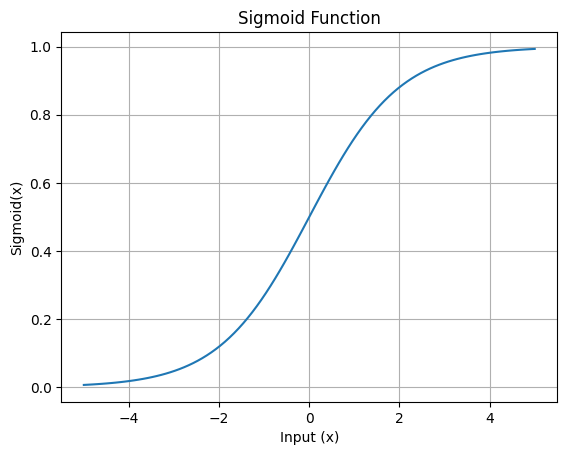

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = 1 / (1 + np.exp(-x))

plt.figure()
plt.plot(x, y)

plt.title('Sigmoid Function')
plt.xlabel('Input (x)')
plt.ylabel('Sigmoid(x)')

plt.grid()
plt.show()

Creates a node in computation graph:
- Value = s
- Parent = self
- Operation = 'sigmoid'

**2. Backward Pass (Gradient Rule)**

```python
def _backward():
    self.grad += s * (1 - s) * out.grad
```

**Gradient formula:**

$$\frac{d}{dx}(\sigma(x)) = \sigma(x)(1 - \sigma(x))$$

**Chain Rule Applied**

$$\frac{dL}{dx} = \frac{dL}{d\sigma} \cdot \frac{d\sigma}{dx}$$

Where:
- out.grad = dL/dσ
- σ(x)(1 - σ(x)) = derivative

In [18]:
import math

class Value:
    def __init__(self, data):
        self.data = data
        self.grad = 0
        self._backward = lambda: None

    def sigmoid(self):
        s = 1 / (1 + math.exp(-self.data))
        out = Value(s)

        def _backward():
            self.grad += s * (1 - s) * out.grad

        out._backward = _backward
        return out

x = Value(0.0)
y = x.sigmoid()

y.grad = 1
y._backward()

print('Gradient:', x.grad)

Gradient: 0.25


**Limitation (Vanishing Gradient)**

- For large |x| → gradient → 0
- Similar to tanh → causes slow learning in deep networks

**Comparison**

| Feature | Sigmoid | ReLU | tanh |
|--------|--------|------|------|
| Range | (0,1) | [0,∞) | (-1,1) |
| Gradient | Small | Stable | Medium |
| Use | Output layer | Hidden layer | Older models |

**One-line Takeaway**

> Sigmoid = smooth probability function but suffers from vanishing gradient

### Comparison Graph of Activation Functions

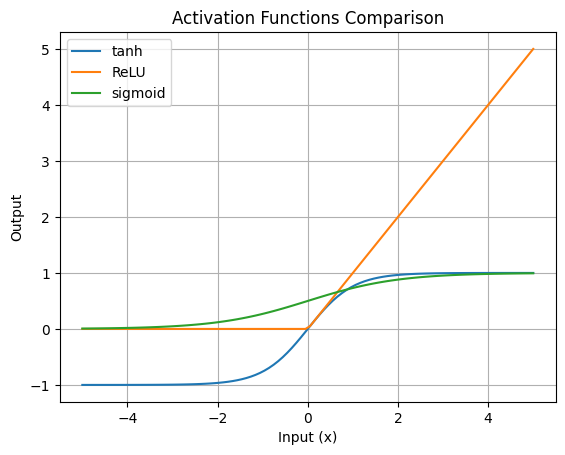

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Generate input values
x = np.linspace(-5, 5, 100)

# Activation functions
tanh_y = np.tanh(x)
relu_y = np.maximum(0, x)
sigmoid_y = 1 / (1 + np.exp(-x))

# Plot
plt.figure()
plt.plot(x, tanh_y, label="tanh")
plt.plot(x, relu_y, label="ReLU")
plt.plot(x, sigmoid_y, label="sigmoid")

# Labels
plt.title("Activation Functions Comparison")
plt.xlabel("Input (x)")
plt.ylabel("Output")

# Legend
plt.legend()

# Grid
plt.grid()

plt.show()

## Understanding `backward()`

**Understand this core logic**
```python
def backward(self):
    topo = []
    visited = set()

    def build(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build(child)
            topo.append(v)
```

**Build a Computational Graph**

We define:

```
z = x * y + x
```

This creates a graph with shared nodes.

In [ ]:
x = Value(2.0, label='x')
y = Value(3.0, label='y')

q = x * y
q.label = 'q = x*y'

z = q + x
z.label = 'z = q + x'
# if get error then run full engine cell it will work

**Visualize Forward Graph**

This shows dependencies before backpropagation.

In [27]:
from graphviz import Digraph


def trace(root):
    """
    Collect all nodes and edges in the graph.
    """
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    """
    Visualize computational graph using Graphviz.
    """
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    # Create nodes
    for n in nodes:
        uid = str(id(n))

        # Node with value + gradient
        dot.node(
            name=uid,
            label=f"{n.label} | data={n.data:.4f} | grad={n.grad:.4f}",
            shape="record"
        )

        # Operation node
        if n._op:
            dot.node(uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    # Create edges
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

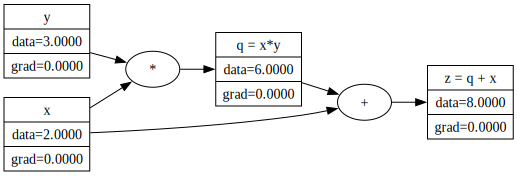

In [28]:
draw_dot(z)

**Topological order** 
- Topological order ensures correct execution order in dependency-based systems like backpropagation
- Topological Order
> x → y → (x*y) → (+) → z
- Reverse Order
> z → (+) → (x*y) → y → x

In [29]:
# ---------------------------------------------------
#    Build Topological Order
# ---------------------------------------------------

topo = []
visited = set()

def build(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build(child)
        topo.append(v)

build(z)

# ---------------------------------------------------
#   Show Topological Order
# ---------------------------------------------------

print("\n Topological Order (Forward Direction):")
for node in topo:
    print(node.label or node._op or "value")

# ---------------------------------------------------
#    Reverse Order (Backprop)
# ---------------------------------------------------

print("\n🔁 Reverse Order (Backpropagation):")
for node in reversed(topo):
    print(node.label or node._op or "value")


 Topological Order (Forward Direction):
y
x
q = x*y
z = q + x

🔁 Reverse Order (Backpropagation):
z = q + x
q = x*y
x
y


**Build Topological Order Manually**

We simulate the `build()` function to understand traversal.

Key idea:
> Visit dependencies first, then add node

In [30]:
topo = []
visited = set()

def build(v):
    if v not in visited:
        print(f"Visiting: {v.label or v._op or 'value'}")
        visited.add(v)

        for child in v._prev:
            build(child)

        print(f"Adding to topo: {v.label or v._op or 'value'}")
        topo.append(v)

build(z)

print("\nTopological Order:")
for node in topo:
    print(node.label or node._op or 'value')

Visiting: z = q + x
Visiting: q = x*y
Visiting: y
Adding to topo: y
Visiting: x
Adding to topo: x
Adding to topo: q = x*y
Adding to topo: z = q + x

Topological Order:
y
x
q = x*y
z = q + x


**Interpret Topological Order**

You should observe:

```
x → y → (x*y) → (+) → z
```

This ensures:

> Dependencies come first
> Safe gradient computation


**Backpropagation (Reverse Order)**

Gradients flow **backwards**:

```
z → (+) → (x*y) → x, y
```

In [34]:
z.backward()

print("dz/dx:", x.grad)
print("dz/dy:", y.grad)

dz/dx: 11.0
dz/dy: 6.0


**How gradient becomes** 
```
dz/dx = 4.0
dz/dy = 2.0
```

Expression

```python
z = x * y + x
```

In [35]:
x = Value(2.0, label='x')
y = Value(3.0, label='y')

q = x * y
q.label = 'q = x*y'

z = q + x
z.label = 'z = q + x'

> **Computational Graph (Forward)**

Notice:
- `x` is used twice
- This creates multiple gradient paths

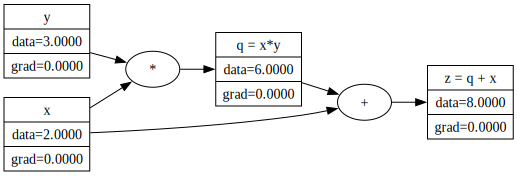

In [36]:
draw_dot(z)

> **Forward Pass (Values)**

| Node | Expression | Value |
|------|-----------|-------|
| x    | input     | 2     |
| y    | input     | 3     |
| q    | x * y     | 6     |
| z    | q + x     | 8     |

> **Backward Pass Starts**

```python
z.backward()
```

initialize:

```
dz/dz = 1
```

In [37]:
z.backward()

print("dz/dx:", x.grad)
print("dz/dy:", y.grad)

dz/dx: 4.0
dz/dy: 2.0


> **Backprop Through Addition**

From:

```
z = q + x
```

Gradient rules:

```
dz/dq = 1
dz/dx = 1
```

So:

```
q.grad = 1
x.grad = 1
```

> **Backprop Through Multiplication**

From:

```
q = x * y
```

Gradient rules:

```
dq/dx = y = 3
dq/dy = x = 2
```

Multiply by upstream gradient (q.grad = 1):

```
x.grad += 3
y.grad += 2
```

> **Gradient Accumulation**

**For x:**

```
From +  → 1
From *  → 3
Total   → 4
```

**For y:**

```
From * → 2
```

**Graph After Backpropagation**


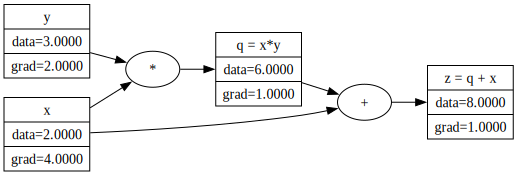

In [38]:
draw_dot(z)

**Key Point**

> A node is processed only after all nodes it depends on are processed.

> If a variable contributes through multiple paths, its gradient is the sum of all paths.

> Chain Rule (Mathematical View)

```
z = x*y + x
```

```
dz/dx = y + 1 = 3 + 1 = 4
dz/dy = x = 2

> Gradient = sum of all influence paths from variable to output

# Final Engine

In [1]:
import math


class Value:

    def __init__(self, data, children=(), _op='', label=''):
        self.data = float(data)
        self.grad = 0.0

        self._backward = lambda: None
        self._prev = set(children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only int/float powers supported"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data**(other - 1)) * out.grad

        out._backward = _backward
        return out


    def tanh(self):
        t = (math.exp(2*self.data) - 1) / (math.exp(2*self.data) + 1)  
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0, self.data), (self,), 'relu')  

        def _backward():
            self.grad += (1.0 if self.data > 0 else 0.0) * out.grad

        out._backward = _backward
        return out

    def sigmoid(self):
        s = 1 / (1 + math.exp(-self.data))
        out = Value(s, (self,), 'sigmoid')  

        def _backward():
            self.grad += s * (1 - s) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)

        build(self)

        # initialize gradient of output
        self.grad = 1.0

        # backpropagation
        for node in reversed(topo):
            node._backward()

# Test Core AutoGradient Engine

In [40]:
a = Value(2.0)
b = Value(3.0)

c = a * b + a
c.backward()

print("c:", c)
print("grad a:", a.grad)
print("grad b:", b.grad)

c: Value(data=8.0, grad=1.0)
grad a: 4.0
grad b: 2.0


## Meaning of gradients

### Code Example

```python
a = Value(2.0)
b = Value(3.0)

c = a * b + a
c.backward()
```

### Final Output

```text
grad a: 4.0
grad b: 2.0
```

### What is a Gradient?

> Gradient = **rate of change of output with respect to input**

### Mathematical Expression

$$c = a \cdot b + a$$

### Gradient with respect to `a`

$$\frac{\partial c}{\partial a} = b + 1 = 3 + 1 = 4$$

### Gradient with respect to `b`

$$\frac{\partial c}{\partial b} = a = 2$$

### Interpretation

### grad a = 4.0

If `a` increases by 1 unit, output increases by 4.

Example:

$$c = 3 \cdot 3 + 3 = 12$$

Previous value:

$$c = 8$$

Change:

$$12 - 8 = 4$$

### grad b = 2.0

If `b` increases by 1 unit, output increases by 2.

Example:

$$c = 2 \cdot 4 + 2 = 10$$

Previous value:

$$c = 8$$

Change:

$$10 - 8 = 2$$

### Why does `a` have a larger gradient?

Because it affects the output in **two places**:

```python
c = a*b + a
    ↑     ↑
  path 1  path 2
```

Contribution:
- From `a*b` → 3
- From `+a` → 1

$$3 + 1 = 4$$

### Why does `b` have a smaller gradient?

`b` appears only once:

```python
c = a*b + a
      ↑
  single path
```

$$\frac{\partial c}{\partial b} = a = 2$$

- Gradients guide weight updates
- Larger gradient → stronger influence

# Neural Network Components

## Neuron

In [41]:
import random

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self, x):
        x = [xi if isinstance(xi, Value) else Value(xi) for xi in x]
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()
    
    def parameters(self):
        return self.w + [self.b]


### Mathematical Representation

$$\text{output} = \tanh\left(\sum_{i=1}^{n} w_i x_i + b\right)$$

This is a **single artificial neuron**

**Core Concepts**

**What is a Weight?**

- A **weight (w)** controls the importance of an input
- Each input has its own weight

$$w_i x_i$$

**Intuition:**
- Large weight → input is important
- Small weight → input is less important

Like giving "priority" to features

**What is Bias?**

- Bias (b) is an **extra constant added to the neuron**

$$\sum w_i x_i + b$$

** Intuition: **
- Shifts the output left/right
- Helps the model fit data better

Without bias, model is too restricted

**Need of weights and bias**

- Weights → learn relationships
- Bias → adjust flexibility

Together they allow the neuron to **learn patterns from data**

**Code Breakdown**

**Initialization**

```python
self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
self.b = Value(random.uniform(-1,1))
```

- Random weights → break symmetry
- Bias initialized randomly

**Forward Pass**

```python
act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
```

Computes:

$$w_1x_1 + w_2x_2 + ... + w_nx_n + b$$

**Activation Function**

```python
return act.tanh()
```

- Adds **non-linearity**
- Allows learning complex patterns

**Activation Function Options**

**Replace with ReLU**

```python
return act.relu()
```

**Replace with Sigmoid**

```python
return act.sigmoid()
```

**Comparison of Activation Functions**

| Feature | tanh | ReLU | Sigmoid |
|--------|------|------|---------|
| Range | (-1, 1) | [0, ∞) | (0, 1) |
| Centered | Yes | No | No |
| Gradient Issue | Vanishing | Minimal | Strong vanishing |
| Speed | Medium | Fast | Slow |
| Usage | Medium | High | Output layer |

**Gradient Behavior**

**tanh:**
$$1 - \tanh^2(x)$$

**sigmoid:**
$$\sigma(x)(1 - \sigma(x))$$

**ReLU:**
$$1 \text{ or } 0$$

> Activation function decides how a neuron "fires"

- tanh → smooth signal
- ReLU → on/off switch 
- sigmoid → probability output

## Layer

In [42]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]



### Mathematical Representation

$$\text{Layer output} = \begin{bmatrix} n_1(x) \\ n_2(x) \\ \vdots \\ n_{out}(x) \end{bmatrix}$$

A **Layer = multiple neurons working in parallel**

**Line-by-line Breakdown**

**Initialization**

```python
self.neurons = [Neuron(nin) for _ in range(nout)]
```

- `nin` → number of inputs
- `nout` → number of neurons

$$n_{out} \text{ neurons each taking } n_{in} \text{ inputs}$$

**Example**

```python
Layer(3, 4)
```

- 4 neurons
- each takes 3 inputs

**Forward Pass**

```python
outs = [n(x) for n in self.neurons]
```

$$\text{outs} = [n_1(x), n_2(x), ..., n_{out}(x)]$$

**Output Handling**

```python
return outs[0] if len(outs) == 1 else outs
```

- Single neuron → scalar output
- Multiple neurons → list output

**Output Examples**

| Layer | Output |
|------|--------|
| Layer(3,1) | single value |
| Layer(3,4) | list of 4 values |

**Parameters Collection**

```python
return [p for n in self.neurons for p in n.parameters()]
```

Flattens all weights and biases from every neuron

**Neuron vs Layer**

| Component | Meaning |
|----------|--------|
| Neuron | Single computation unit |
| Layer | Collection of neurons |

**Computational View**

```text
Input x
   ↓
[Neuron 1] → y1
[Neuron 2] → y2
[Neuron 3] → y3
   ↓
Output = [y1, y2, y3]
```

- Single neuron → limited (linear-ish)
- Multiple neurons → richer feature extraction

Enables learning complex patterns

**Role in Neural Network**

```text
Input → Layer → Layer → Layer → Output
```

> A layer is a **team of neurons**, each learning a different feature

- Neuron 1 → detects pattern A
- Neuron 2 → detects pattern B
- Together → powerful representation

> Each neuron has its own weights and bias

- Neuron 1 learns one feature
- Neuron 2 learns another

**Matrix Form Connection**

$$y = Wx + b$$

- W → weight matrix
- b → bias vector

> Layer = parallel neurons transforming input into a feature vector

### Example Usage

In [43]:
layer = Layer(3, 2)

x = [Value(1.0), Value(2.0), Value(3.0)]

out = layer(x)
print(out)

[Value(data=0.9073465875558713, grad=0.0), Value(data=0.6689335259026876, grad=0.0)]


**Explanation**
```python
Layer(3, 2)
```

- 3 inputs
- 2 neurons

Each neuron has:
- 3 weights
- 1 bias


**Layer Execution**

```python
def __call__(self, x):
    outs = [n(x) for n in self.neurons]
```

Each neuron processes the same input:

```
out = [Neuron1(x), Neuron2(x)]

**Neuron Computation**

Each neuron performs:

```python
act = sum(wi * xi) + b
return tanh(act)
```

Mathematically:

$$z = \sum w_i x_i + b$$
$$y = \tanh(z)$$

**Example: Neuron 1**

Assume:

```
w1 = 0.5
w2 = -0.2
w3 = 0.8
b  = 0.1
```

Input:

```
x = [1.0, 2.0, 3.0]
```

> Weighted Sum

$$z = (0.5 \cdot 1) + (-0.2 \cdot 2) + (0.8 \cdot 3) + 0.1$$
$$z = 2.6$$

> Activation

$$\tanh(2.6) \approx 0.99$$

Output of Neuron 1 ≈ 0.99

**Example: Neuron 2**

Assume:

```
w4 = -0.3
w5 = 0.6
w6 = -0.5
b  = -0.2
```

> Step 1:

$$z = (-0.3 \cdot 1) + (0.6 \cdot 2) + (-0.5 \cdot 3) - 0.2$$
$$z = -0.8$$

> Step 2:

$$\tanh(-0.8) \approx -0.66$$

Output of Neuron 2 ≈ -0.66

**Why output is different every time**

Because of random initialization:

```python
random.uniform(-1,1)
```

- Weights change
- Output changes

**Why gradients are zero?**

Only forward pass is executed.

No backpropagation:

```python
out.backward()
```

So:

```
grad = 0.0
```

**Full Flow**

```
Input x = [1,2,3]

        ↓
Neuron 1 → y1
Neuron 2 → y2
        ↓
Output = [y1, y2]
```

> Each neuron performs
- **Linear transformation + Non-linear activation**
- **Layer = Parallel neuron computations → Feature vector output**

## MLP

In [44]:
class MLP:
    def __init__(self,nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

### MLP Represents

Example:

```python
MLP(3, [4, 4, 1])
```

```
Input (3)
   ↓
Layer 1 (4 neurons)
   ↓
Layer 2 (4 neurons)
   ↓
Layer 3 (1 neuron)
   ↓
Output
```

**Visual Represents**

In [45]:
from graphviz import Digraph

def draw_mlp(nin, nouts):
    dot = Digraph(format='png')
    dot.attr(rankdir='LR')  # Left → Right layout

    # Create layer sizes
    sz = [nin] + nouts

    layers = []

    # 🔹 Create nodes
    for i, layer_size in enumerate(sz):
        layer_nodes = []
        for j in range(layer_size):
            node_name = f"L{i}N{j}"
            
            if i == 0:
                label = f"x{j+1}"
            elif i == len(sz) - 1:
                label = f"y{j+1}"
            else:
                label = f"h{i}_{j+1}"
            
            dot.node(node_name, label=label, shape='circle')
            layer_nodes.append(node_name)
        
        layers.append(layer_nodes)

    # 🔹 Create edges (fully connected)
    for i in range(len(layers) - 1):
        for src in layers[i]:
            for dst in layers[i+1]:
                dot.edge(src, dst)

    return dot

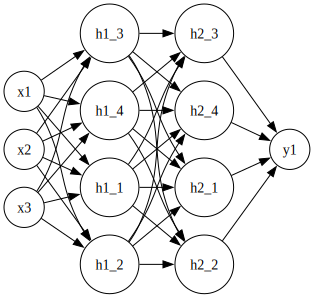

In [46]:
model_graph = draw_mlp(3, [4, 4, 1])
#input(3), 2 hidden layer with (4) neuron, 1 out put neuron
model_graph

**Network Construction**

```python
sz = [nin] + nouts
```

Example:

```python
nin = 3
nouts = [4, 4, 1]
sz = [3, 4, 4, 1]
```

Layers created:

```python
[Layer(3,4), Layer(4,4), Layer(4,1)]
```

**Forward Pass**

```python
for layer in self.layers:
    x = layer(x)
```

Flow:

```
x → Layer1 → Layer2 → Layer3 → output
```

Step-by-step:

```python
x1 = Layer1(x)
x2 = Layer2(x1)
x3 = Layer3(x2)
```

**Mathematical Representation**

$$y = L_3(L_2(L_1(x)))$$

This represents nested function composition.

**Parameters Collection**

```python
return [p for layer in self.layers for p in layer.parameters()]
```

Used in optimization:

```python
for p in model.parameters():
    p.data -= lr * p.grad
```

**Zero Gradients**

```python
for p in self.parameters():
    p.grad = 0.0
```

Why?

Gradients accumulate:

```python
self.grad += ...
```

**Full Pipeline**

```
Input x
   ↓
Layer 1 → features
   ↓
Layer 2 → higher features
   ↓
Layer 3 → prediction
   ↓
Loss
   ↓
backward()
   ↓
Gradients flow back
```

> MLP = Stack of layers learning hierarchical patterns

- Layer 1 → basic features
- Layer 2 → combinations
- Layer 3 → final decision
- Single layer → limited learning
- Multiple layers → complex patterns & nonlinear boundaries
- This is a **fully connected neural network (feedforward network)**
- **MLP = Sequential composition of layers transforming input → output**
- Forward pass
- Backward pass
- Parameter tracking


# Final NN Components

In [47]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        x = [xi if isinstance(xi, Value) else Value(xi) for xi in x]
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0


# Training Example

## Model

In [48]:
model = MLP(3, [4,4,1])

## Dataset genaration

In [49]:
data = [
    ([2.0,3.0,-1.0], 1.0),
    ([3.0,-1.0,0.5], -1.0),
    ([0.5,1.0,1.0], -1.0),
    ([1.0,1.0,-1.0], 1.0)
]


> Dataset Structure

Each data point is represented as:

```
(input_features, target_output)
```

Example:

```
([2.0, 3.0, -1.0], 1.0)
```

- Input → 3 features (because model expects 3 inputs)
- Output → single scalar target

> Why this format?

- The model is defined as:
```
MLP(3, [4,4,1])
```

Meaning:
- 3 input neurons → requires 3 input values
- 1 output neuron → produces single output

So each data point must match this structure.

> Labels 

- Targets are `1.0` and `-1.0`
- This matches the output range of `tanh`:

$$(-1, 1)$$

So:
- `1.0` → positive class
- `-1.0` → negative class

## Training Loop

In [50]:
model = MLP(3, [4,4,1])

for epoch in range(20):
    total_loss = 0

    for x,y in data:
        pred = model(x)
        loss =(pred - y)**2

        model.zero_grad()
        loss.backward()

        for p in model.parameters():
            p.data += -0.05 * p.grad

        total_loss += loss.data
    
    print(f"Epoch {epoch}: Loss {total_loss}")

Epoch 0: Loss 5.917611543862639
Epoch 1: Loss 5.431213797632582
Epoch 2: Loss 5.152773163890538
Epoch 3: Loss 4.923821374816919
Epoch 4: Loss 4.704008468923312
Epoch 5: Loss 4.494067338422293
Epoch 6: Loss 4.303071511399386
Epoch 7: Loss 4.138375079868589
Epoch 8: Loss 4.00297961895901
Epoch 9: Loss 3.895560387425028
Epoch 10: Loss 3.812055059806526
Epoch 11: Loss 3.747554661199098
Epoch 12: Loss 3.6975396014444923
Epoch 13: Loss 3.6583550362116606
Epoch 14: Loss 3.6272326394147054
Epoch 15: Loss 3.6021391490865295
Epoch 16: Loss 3.581597910540756
Epoch 17: Loss 3.564536650985488
Epoch 18: Loss 3.550171891665668
Epoch 19: Loss 3.5379255354659476


**Epoch Loop**
```python
for epoch in range(20):
```
- One epoch = one full pass over dataset
- Model improves after each epoch

**Initialize Loss**
```python
total_loss = 0
```
- Tracks total error

**Dataset Iteration**
```python
for x, y in data:
```
- x → input
- y → target

**Forward Pass**
```python
pred = model(x)
```

$$\hat{y} = f(x)$$

Flow:
x → Layer1 → Layer2 → Layer3 → pred

**Loss Function**
```python
loss = (pred - y) ** 2
```

$$L = (\hat{y} - y)^2$$

**Reset Gradients**
```python
model.zero_grad()
```
- Prevents accumulation

**Backpropagation**
```python
loss.backward()
```

$$\frac{\partial L}{\partial w}$$

- Computes gradients using chain rule

**Parameter Update**
```python
for p in model.parameters():
    p.data += -0.05 * p.grad
```

$$w = w - \eta \cdot \frac{\partial L}{\partial w}$$

**Track Loss**
```python
total_loss += loss.data
```

**Monitor Training**
```python
print(f"Epoch {epoch}: Loss {total_loss}")
```

Expected:
Epoch 0: High loss
Epoch 1: Lower loss

> Full Pipeline

Input -> Forward -> Loss -> Backward -> Update -> Repeat

# Final Training

In [71]:
model = MLP(3, [4,4,1])

data = [
    ([2.0,3.0,-1.0], 1.0),
    ([3.0,-1.0,0.5], -1.0),
    ([0.5,1.0,1.0], -1.0),
    ([1.0,1.0,-1.0], 1.0)
]

for epoch in range(20):
    total_loss = 0

    for x, y in data:
        pred = model(x)
        loss = (pred - y)**2

        model.zero_grad()
        loss.backward()

        for p in model.parameters():
            p.data += -0.05 * p.grad

        total_loss += loss.data

    print(f"Epoch {epoch}: Loss {total_loss}")

Epoch 0: Loss 5.480536783103721
Epoch 1: Loss 1.1953520796534736
Epoch 2: Loss 0.4383083360179553
Epoch 3: Loss 0.27950796113629317
Epoch 4: Loss 0.2073523873314533
Epoch 5: Loss 0.165102967598592
Epoch 6: Loss 0.13715748146827073
Epoch 7: Loss 0.11724707558962896
Epoch 8: Loss 0.10232432255354568
Epoch 9: Loss 0.09071854774889855
Epoch 10: Loss 0.08143358590933779
Epoch 11: Loss 0.0738371931848969
Epoch 12: Loss 0.06750819252087607
Epoch 13: Loss 0.062154927841975766
Epoch 14: Loss 0.0575689153074975
Epoch 15: Loss 0.05359711509219943
Epoch 16: Loss 0.05012462506295583
Epoch 17: Loss 0.04706348693096454
Epoch 18: Loss 0.04434522190719811
Epoch 19: Loss 0.04191572029021149


# Final Output

In [72]:
for x, y in data:
    print(x, model(x).data)

[2.0, 3.0, -1.0] 0.9305314980380672
[3.0, -1.0, 0.5] -0.9398141183207858
[0.5, 1.0, 1.0] -0.8796204769769073
[1.0, 1.0, -1.0] 0.8722166259461424
